In [3]:
!pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Load the dataset
df = pd.read_csv('../data_raw//WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look at the data
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Understand the data structure
print("Column Names & Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Column Names & Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pa

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Fix TotalCharges - convert to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many blank spaces were hiding
print("Missing values in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Drop those rows - only 11 so we lose nothing significant
df.dropna(inplace=True)

# Confirm
print("Dataset shape after cleaning:", df.shape)
print("TotalCharges dtype now:", df['TotalCharges'].dtype)

Missing values in TotalCharges after fix: 11
Dataset shape after cleaning: (7032, 21)
TotalCharges dtype now: float64


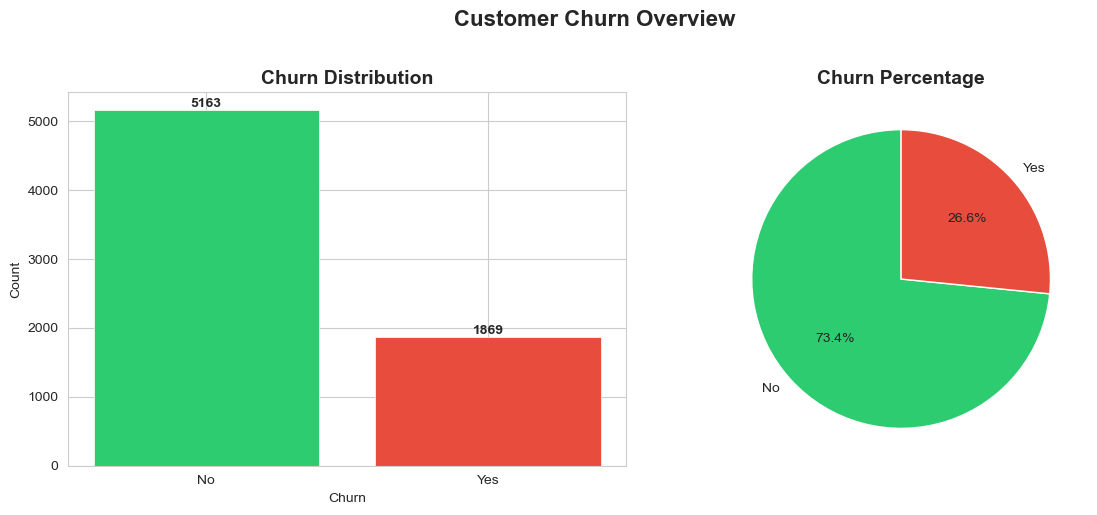

✅ Chart saved!


In [9]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

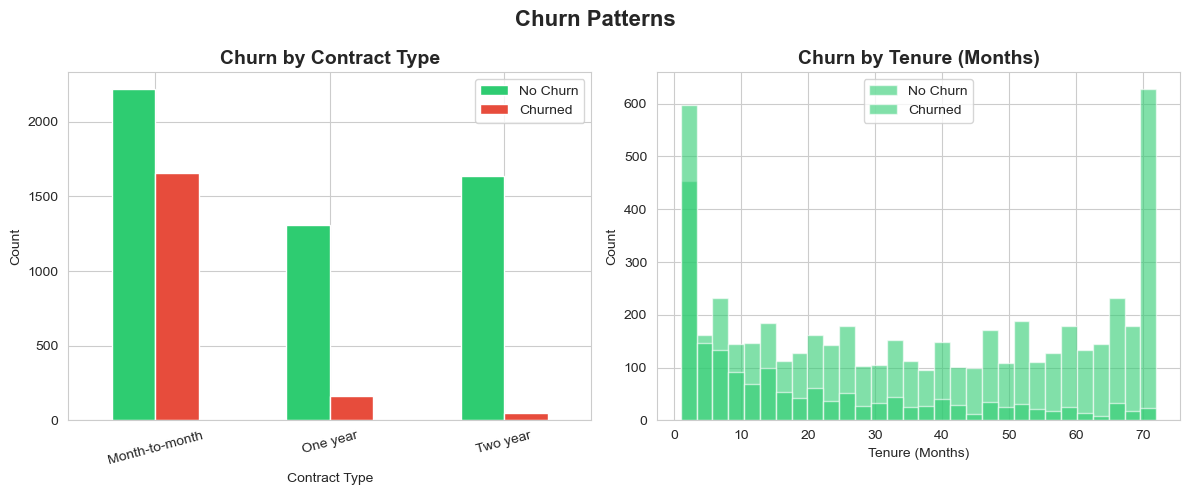

✅ Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn by Contract Type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], 
                    edgecolor='white')
axes[0].set_title('Churn by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['No Churn', 'Churned'])

# Churn by Tenure
df.groupby('Churn')['tenure'].plot(kind='hist', ax=axes[1], 
                                    alpha=0.6, bins=30,
                                    color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn by Tenure (Months)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Count')
axes[1].legend(['No Churn', 'Churned'])

plt.suptitle('Churn Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/02_churn_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

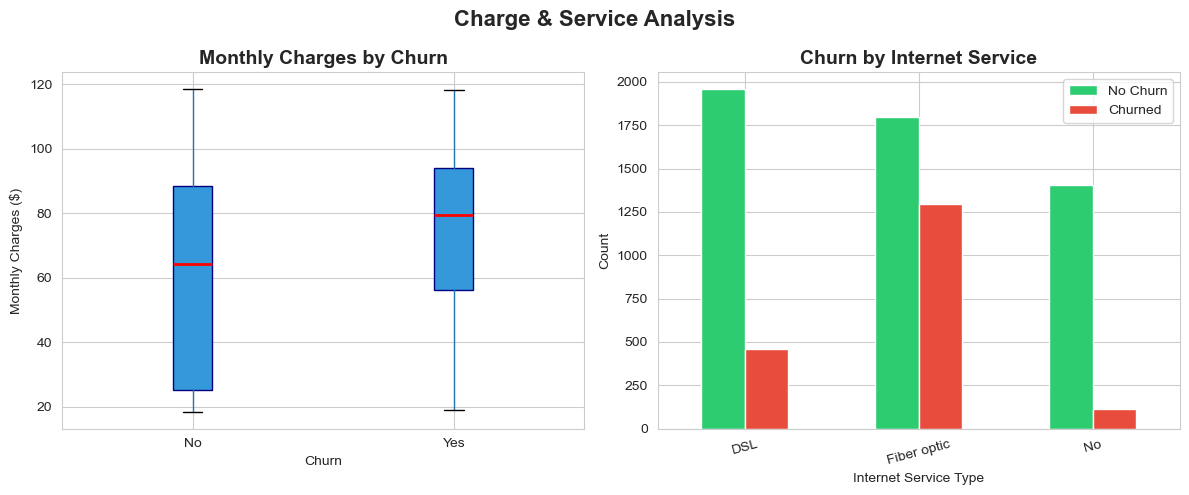

✅ Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Monthly Charges by Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')
plt.sca(axes[0])
plt.title('Monthly Charges by Churn', fontsize=14, fontweight='bold')

# Internet Service by Churn
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[1], 
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='white')
axes[1].set_title('Churn by Internet Service', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['No Churn', 'Churned'])

plt.suptitle('Charge & Service Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/03_charges_service_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [12]:
# Drop customerID - useless for prediction
df.drop('customerID', axis=1, inplace=True)

# Convert all binary Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 
               'StreamingMovies', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'No phone service': 0, 
                           'No internet service': 0})

# Encode gender
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

print("✅ Preprocessing complete!")
print("Dataset shape:", df.shape)
print("\nAll columns now numeric:")
print(df.dtypes)

✅ Preprocessing complete!
Dataset shape: (7032, 27)

All columns now numeric:
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           bool
Inte

In [13]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data split complete!")
print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set:  {X_test.shape[0]} customers")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing set:  {y_test.mean()*100:.1f}%")

✅ Data split complete!
Training set: 5625 customers
Testing set:  1407 customers

Churn rate in training set: 26.6%
Churn rate in testing set:  26.6%


In [14]:
# Build the three individual models
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced')  # handles class imbalance

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=3,  # handles class imbalance
    eval_metric='logloss',
    verbosity=0)

# Combine into a Voting Classifier ------Hybrid ensemble---
hybrid_model = VotingClassifier(
    estimators=[
        ('random_forest', rf_model),
        ('xgboost', xgb_model)
    ],
    voting='soft')  # soft voting uses probabilities - more accurate

# Train the hybrid model
print("🔄 Training hybrid ensemble model...")
hybrid_model.fit(X_train, y_train)
print("✅ Model trained successfully!")

🔄 Training hybrid ensemble model...
✅ Model trained successfully!


        HYBRID ENSEMBLE MODEL PERFORMANCE
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1033
     Churned       0.56      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC-AUC Score: 0.8192


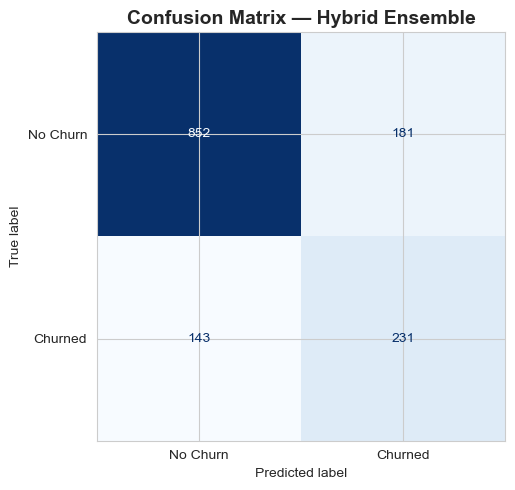

✅ Evaluation complete!


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

# Make predictions
y_pred = hybrid_model.predict(X_test)
y_prob = hybrid_model.predict_proba(X_test)[:, 1]

# Classification Report
print("=" * 55)
print("        HYBRID ENSEMBLE MODEL PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred, 
      target_names=['No Churn', 'Churned']))

# ROC-AUC Score
roc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_score:.4f}")
print("=" * 55)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churned'],
    colorbar=False,
    cmap='Blues',
    ax=ax)
ax.set_title('Confusion Matrix — Hybrid Ensemble', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation complete!")

In [ ]:
# Extract the Random Forest from the hybrid model for SHAP
rf = hybrid_model.named_estimators_['random_forest']

# Convert X_test back to DataFrame with column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Create SHAP explainer
print("🔄 Calculating SHAP values...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

print("✅ SHAP values calculated!")
print(f"Shape of SHAP values: {np.array(shap_values).shape}")

In [21]:
# Check what shape we're working with
print("shap_values type:", type(shap_values))
print("shap_values length:", len(shap_values))
print("X_test_df shape:", X_test_df.shape)

if isinstance(shap_values, list):
    print("shap_values[0] shape:", np.array(shap_values[0]).shape)
    print("shap_values[1] shape:", np.array(shap_values[1]).shape)
else:
    print("shap_values shape:", np.array(shap_values).shape)

shap_values type: <class 'numpy.ndarray'>
shap_values length: 1407
X_test_df shape: (1407, 26)
shap_values shape: (1407, 26, 2)


In [22]:
# Extract class 1 (Churned) SHAP values correctly
shap_vals_churn = shap_values[:, :, 1]

# SHAP Bar Plot - Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_churn, X_test_df, plot_type="bar", 
                  show=False, max_display=15)
plt.title('Top 15 Features Driving Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/05_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved!")


✅ SHAP bar plot saved!


In [23]:
# SHAP Dot Plot - shows direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_churn, X_test_df, 
                  show=False, max_display=15)
plt.title('SHAP Impact on Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/06_shap_impact_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP dot plot saved!")

✅ SHAP dot plot saved!


📊 SHAP Feature Importance:


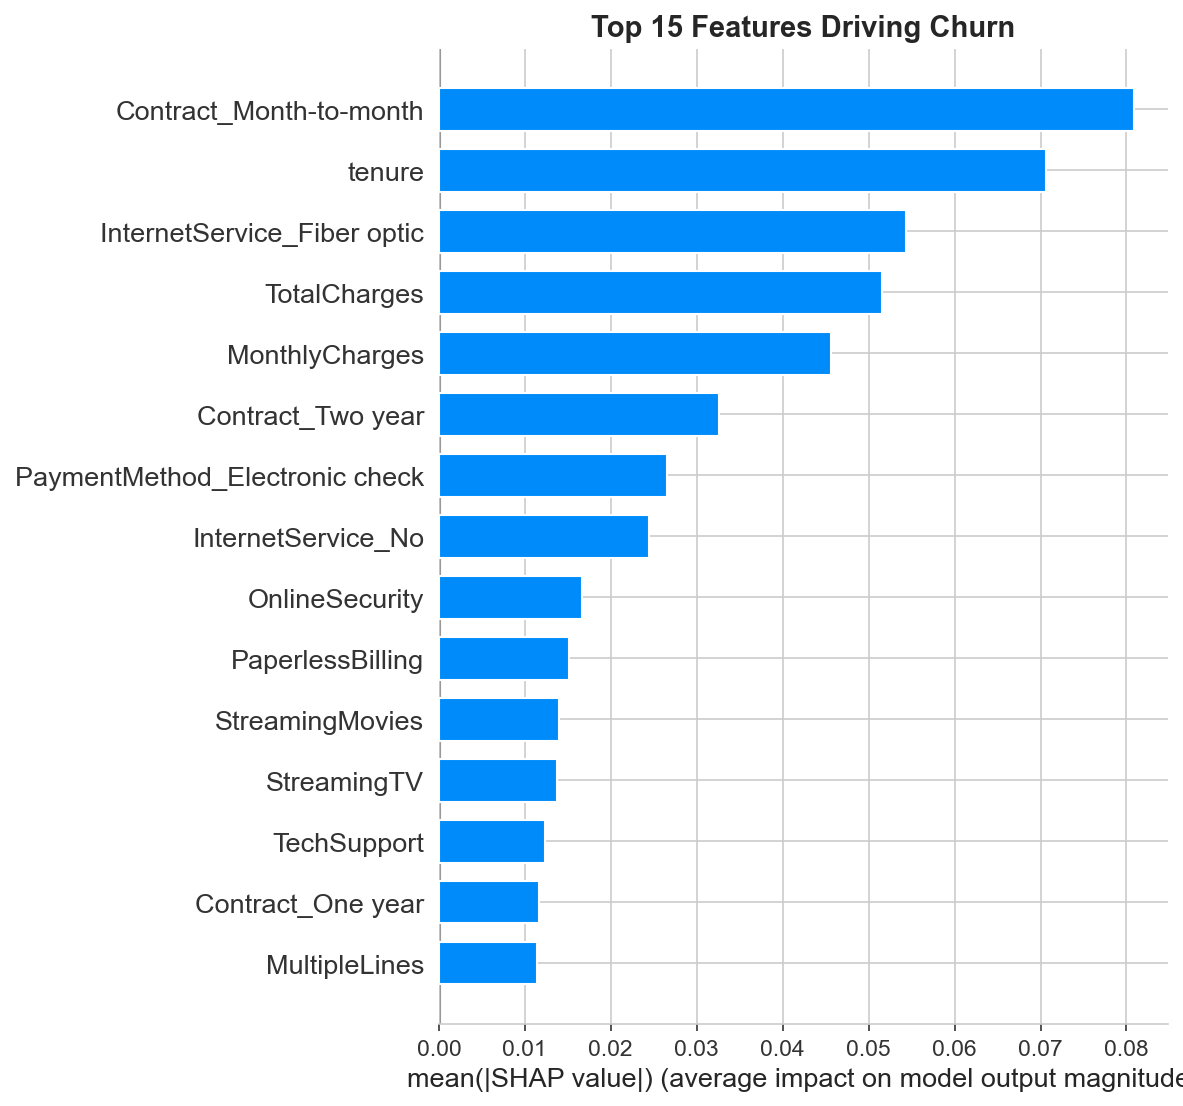


📊 SHAP Impact Plot:


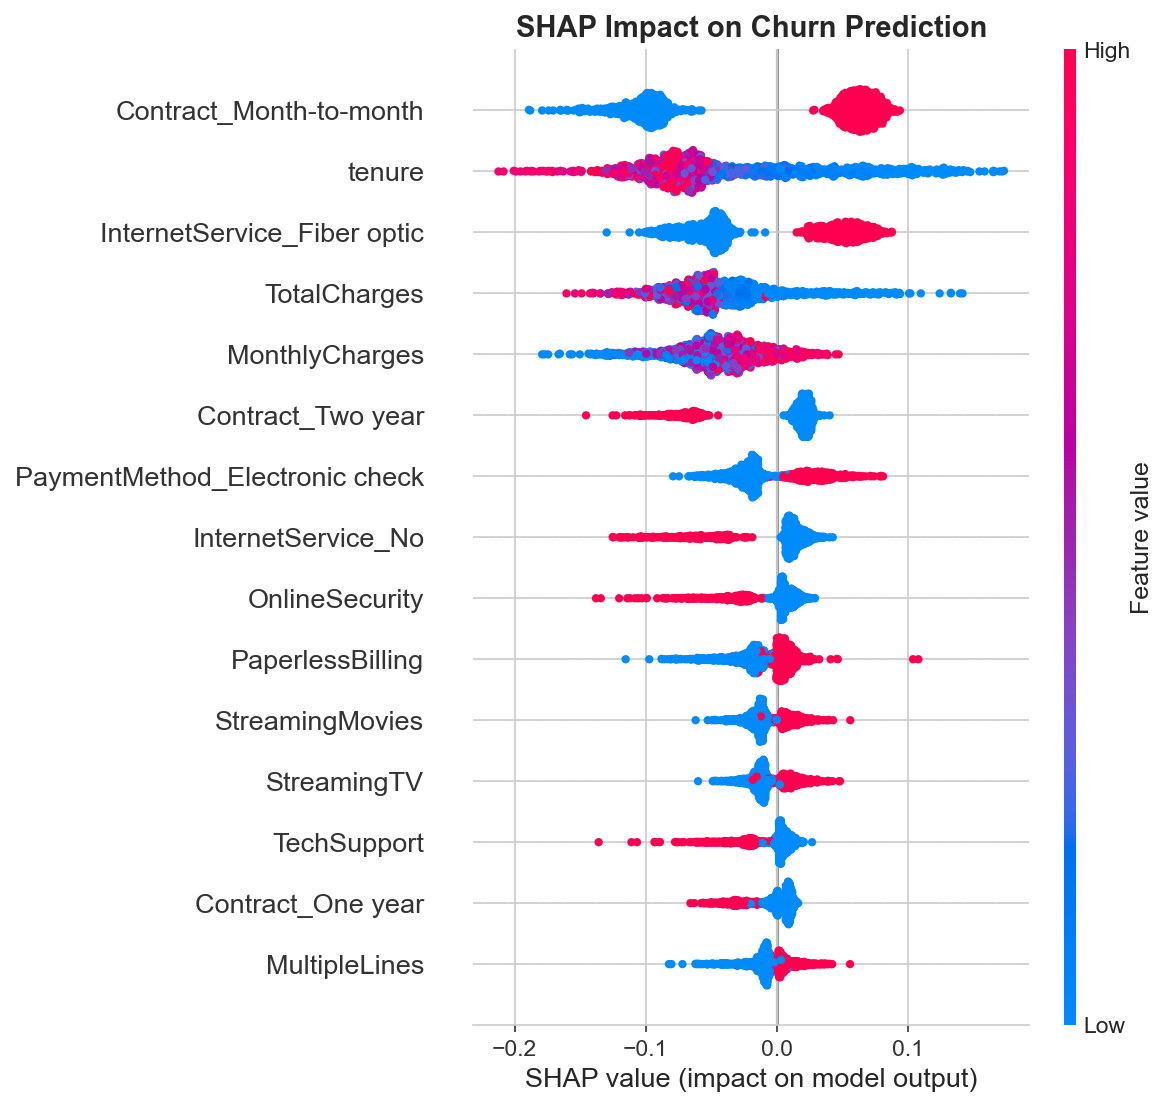

In [26]:

from IPython.display import Image, display

print("📊 SHAP Feature Importance:")
display(Image(filename='../visuals/05_shap_feature_importance.png', width=550))

print("\n📊 SHAP Impact Plot:")
display(Image(filename='../visuals/06_shap_impact_plot.png', width=550))

In [27]:
import joblib

# Save the trained model and scaler
joblib.dump(hybrid_model, '../models/hybrid_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Model saved to models/hybrid_churn_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")

✅ Model saved to models/hybrid_churn_model.pkl
✅ Scaler saved to models/scaler.pkl
